# Bias–Variance Tradeoff with Linear Regression

This notebook builds a **clean synthetic experiment** for demonstrating the bias–variance tradeoff.

## Goal
We want to show how model complexity affects:

- **bias**: systematic error from a model that is too simple
- **variance**: instability from a model that is too sensitive to the training sample
- **test error**: the balance between the two

## Key design choices
This experiment is intentionally clean:

1. We define a known target function.
2. We use a **fixed, dense, noiseless test grid**.
3. For every run, we sample a **new small training set** from a continuous range.
4. We add noise **only to the training targets**.
5. We fit polynomial models of different degrees using linear regression.

This lets us estimate:

- average prediction
- variance across runs
- bias squared relative to the true function

## 1. Imports
We keep the stack small: NumPy, Matplotlib, pandas, and scikit-learn.

In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["axes.grid"] = True

RNG = np.random.default_rng(42)

## 2. Define the true function

We use a smooth nonlinear target:

$$
f(x) = \sin(2\pi x)
$$

A straight line cannot model it well, but polynomial features can approximate it with different levels of flexibility.

In [2]:

def true_function(x):
    return np.sin(2 * np.pi * x)

## 3. Create a fixed test grid

This grid is used in **every run**.

Important:
- the inputs are fixed
- the target values are noiseless
- this makes bias and variance estimation clean

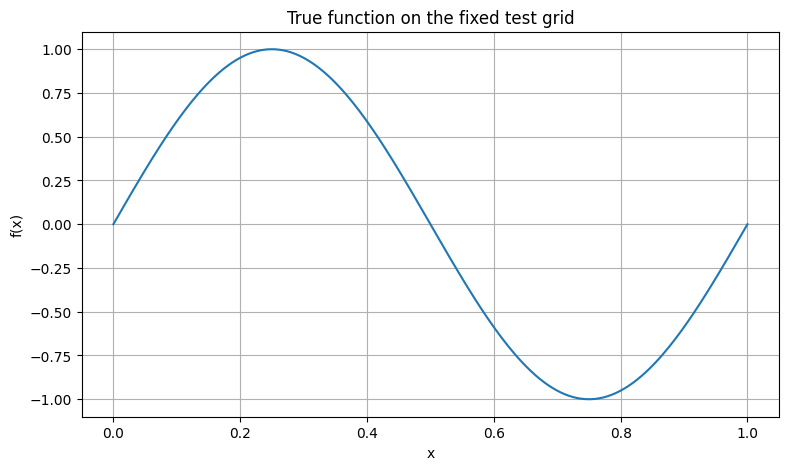

In [3]:

x_min, x_max = 0.0, 1.0
n_test = 300

X_test = np.linspace(x_min, x_max, n_test).reshape(-1, 1)
y_test_true = true_function(X_test).ravel()

plt.plot(X_test, y_test_true)
plt.title("True function on the fixed test grid")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.show()

## 4. Sample a training set

For each run:
- sample `x` values uniformly from the interval
- compute the noiseless target
- add Gaussian noise to create observed training labels

This simulates repeated draws of training data from the same data-generating process.

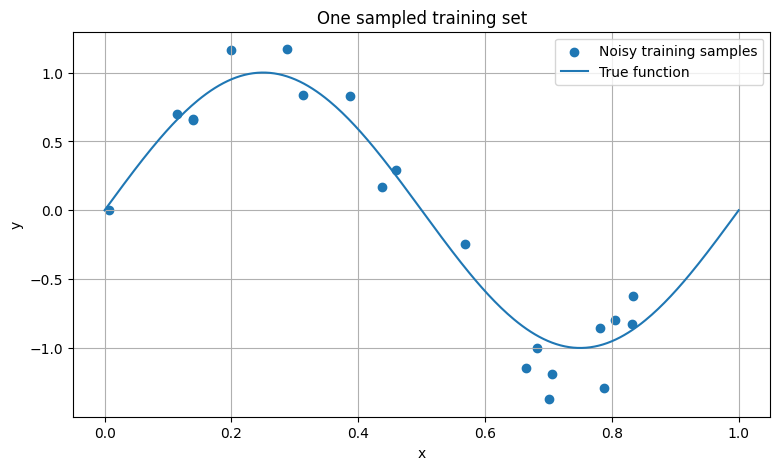

In [22]:
NOISE_STD = 0.25
n_train = 20

def sample_training_data(n_train=20, noise_std=0.25, rng=None):
    if rng is None:
        rng = np.random.default_rng()

    X_train = rng.uniform(x_min, x_max, size=n_train).reshape(-1, 1)
    y_train_clean = true_function(X_train).ravel()
    noise = rng.normal(loc=0.0, scale=noise_std, size=n_train)
    y_train = y_train_clean + noise
    return X_train, y_train, y_train_clean

X_train_demo, y_train_demo, y_train_clean_demo = sample_training_data(
    n_train=n_train,
    noise_std=NOISE_STD,
    rng=RNG
)

plt.scatter(X_train_demo, y_train_demo, label="Noisy training samples")
plt.plot(X_test, y_test_true, label="True function")
plt.title("One sampled training set")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()

## 5. Define the model family

We use **linear regression with polynomial features**.

Example:
- degree 1 = ordinary linear regression
- degree 3 = cubic model
- degree 10 = much more flexible model

Even with polynomial features, the fitted model is still **linear in the parameters**.

In [18]:
def polynomial_features(X, degree):
    """Expand 1D input X into polynomial features [x^1, x^2, ..., x^degree]."""
    X = np.asarray(X).reshape(-1, 1)
    return np.hstack([X ** i for i in range(1, degree + 1)])


def fit_linear_regression_on_poly(X, y, degree):
    X_poly = polynomial_features(X, degree)
    model = LinearRegression()
    model.fit(X_poly, y)
    return model


def predict_with_poly(model, X, degree):
    X_poly = polynomial_features(X, degree)
    return model.predict(X_poly)

## 6. Visual intuition: one fit for several model complexities

Before repeating the experiment many times, it helps to see what one sampled training set looks like under different model complexities.

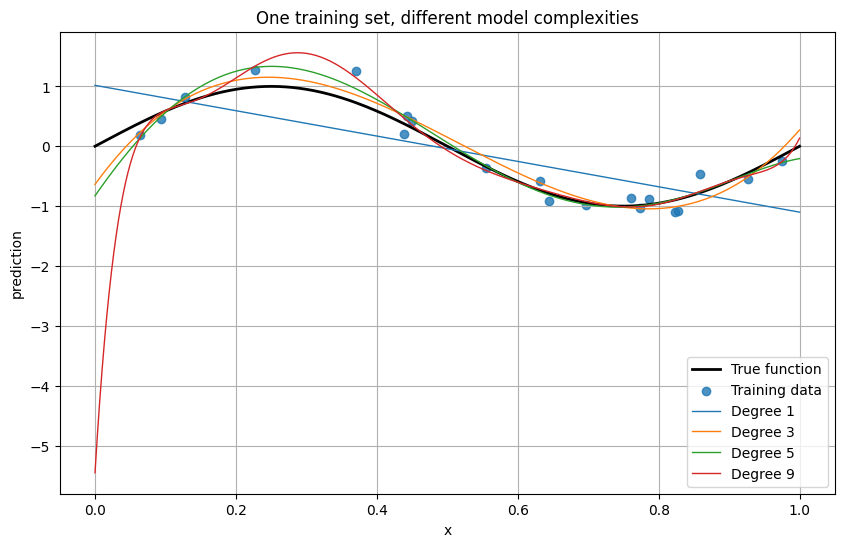

In [ ]:

degrees_demo = [1, 3, 5, 9]

plt.figure(figsize=(10, 6))
plt.plot(X_test, y_test_true, label="True function", linewidth=2, color="black")
plt.scatter(X_train_demo, y_train_demo, label="Training data", alpha=0.8)

for degree in degrees_demo:
    model = fit_linear_regression_on_poly(X_train_demo, y_train_demo, degree)
    y_pred = predict_with_poly(model, X_test, degree)
    plt.plot(X_test, y_pred, label=f"Degree {degree}", linewidth=1)

plt.title("One training set, different model complexities")
plt.xlabel("x")
plt.ylabel("prediction")
plt.ylim(-2, 2)
plt.legend()
plt.show()

## 7. Repeated experiment

Now we run the clean experiment many times.

For each degree:
1. sample a fresh training set
2. fit the model
3. predict on the same fixed test grid
4. store train error and test error

Because the test grid is fixed, we can later compute:
- the mean prediction at each point
- the variance across fitted models
- the squared bias relative to the known true function

In [23]:

def run_experiment(degrees, n_runs, n_train, noise_std, seed):
    rng = np.random.default_rng(seed)
    results = {}

    for degree in degrees:
        predictions = []
        train_mse_list = []
        test_mse_list = []

        for _ in range(n_runs):
            X_train, y_train, _ = sample_training_data(
                n_train=n_train,
                noise_std=noise_std,
                rng=rng
            )

            model = fit_linear_regression_on_poly(X_train, y_train, degree)

            y_train_pred = predict_with_poly(model, X_train, degree)
            y_test_pred = predict_with_poly(model, X_test, degree)

            predictions.append(y_test_pred)
            train_mse_list.append(mean_squared_error(y_train, y_train_pred))
            test_mse_list.append(mean_squared_error(y_test_true, y_test_pred))

        predictions = np.array(predictions)

        mean_prediction = predictions.mean(axis=0)
        prediction_variance = predictions.var(axis=0)
        bias_squared = (mean_prediction - y_test_true) ** 2

        results[degree] = {
            "predictions": predictions,
            "mean_prediction": mean_prediction,
            "variance_per_x": prediction_variance,
            "bias2_per_x": bias_squared,
            "avg_variance": prediction_variance.mean(),
            "avg_bias2": bias_squared.mean(),
            "avg_train_mse": np.mean(train_mse_list),
            "avg_test_mse": np.mean(test_mse_list),
            "train_mse_all": np.array(train_mse_list),
            "test_mse_all": np.array(test_mse_list),
        }

    return results

degrees = [1, 2, 3, 5, 9, 15]
results = run_experiment(degrees, n_runs=60, n_train=n_train, noise_std=NOISE_STD, seed=123)

## 8. Plot multiple fitted curves per degree

This is one of the clearest visualizations.

Interpretation:
- if many fitted curves look similar, the model has lower variance
- if they differ a lot, the model has higher variance
- if all curves miss the true trend, the model has high bias

Text(0, 0.5, 'prediction')

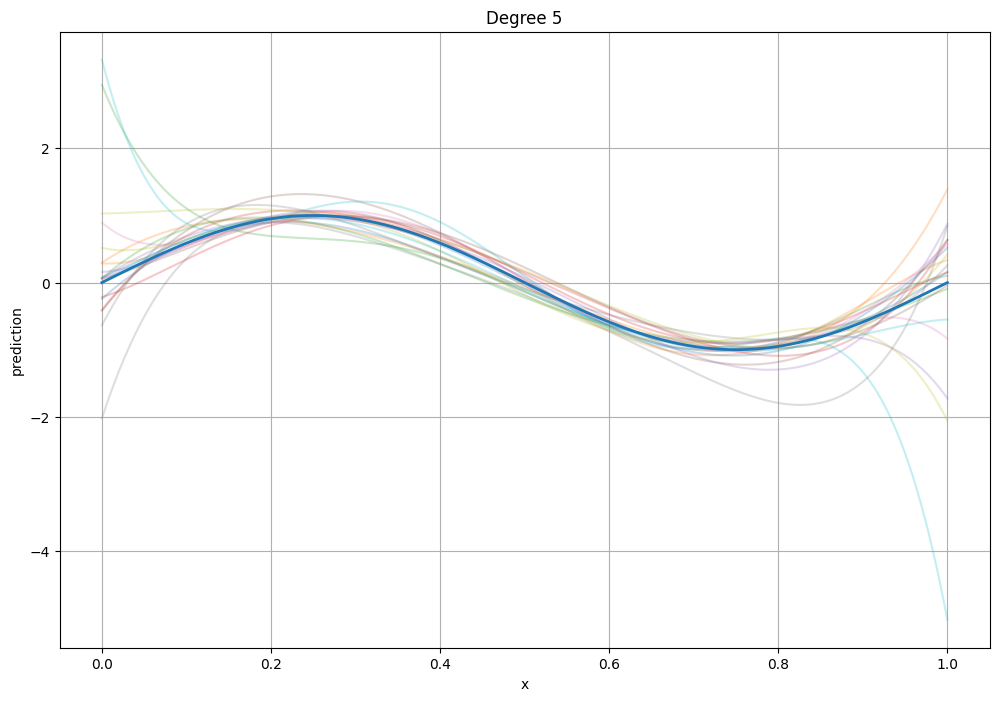

In [29]:
plt.figure(figsize=(12, 8))
degree = degrees[3]  # Change this index to visualize different degrees
preds = results[degree]["predictions"]

for i in range(min(20, preds.shape[0])):
    plt.plot(X_test, preds[i], alpha=0.25)

plt.plot(X_test, y_test_true, linewidth=2, label="True function")
plt.title(f"Degree {degree}")
plt.xlabel("x")
plt.ylabel("prediction")

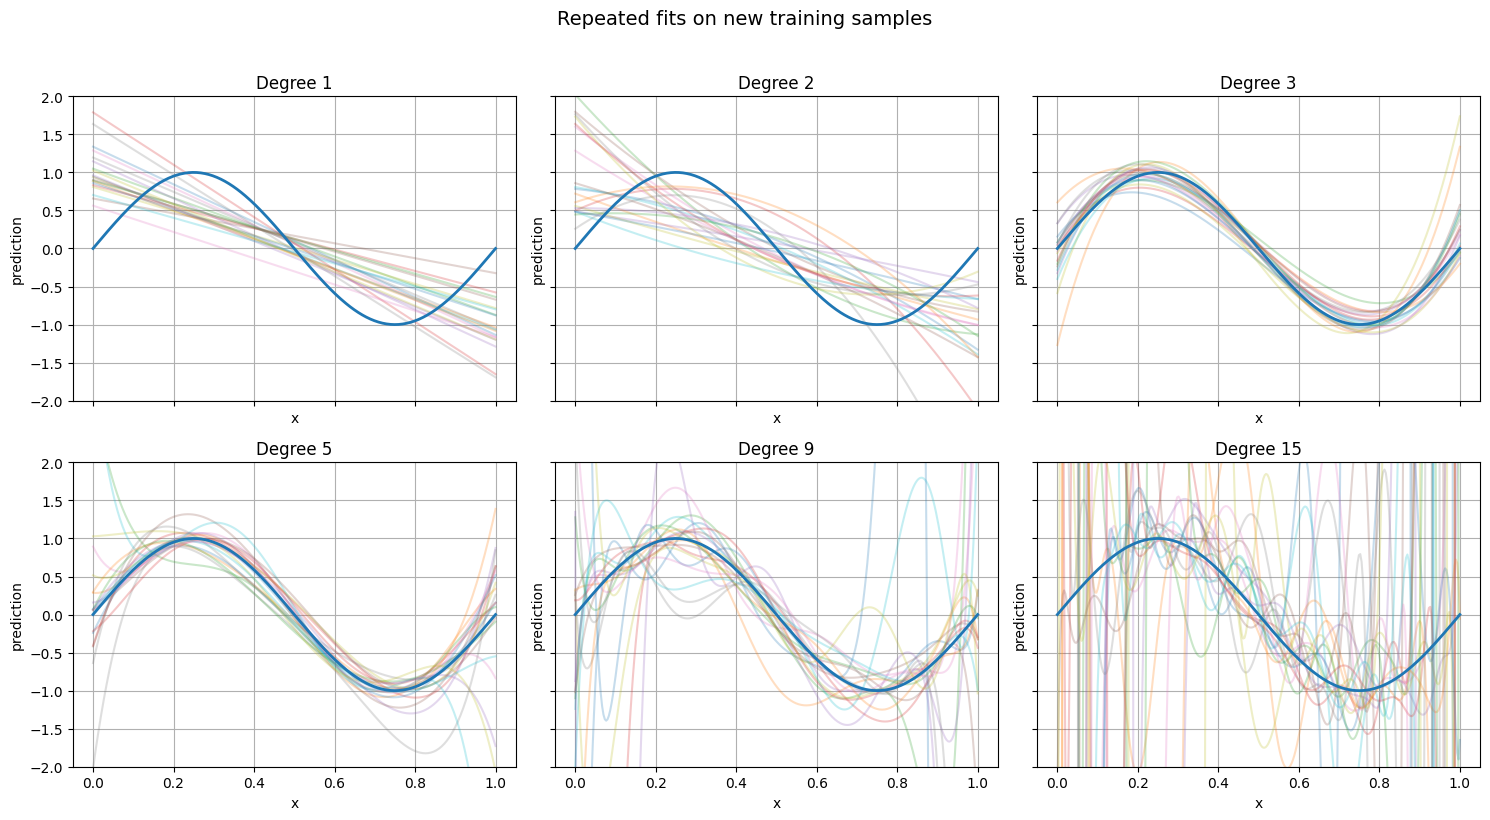

In [30]:

fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharex=True, sharey=True)
axes = axes.ravel()

for ax, degree in zip(axes, degrees):
    preds = results[degree]["predictions"]

    for i in range(min(20, preds.shape[0])):
        ax.plot(X_test, preds[i], alpha=0.25)

    ax.plot(X_test, y_test_true, linewidth=2, label="True function")
    ax.set_title(f"Degree {degree}")
    ax.set_xlabel("x")
    ax.set_ylabel("prediction")
    ax.set_ylim(-2, 2)

plt.suptitle("Repeated fits on new training samples", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

## 9. Mean prediction vs true function

This plot helps explain **bias**.

For each degree:
- the average fitted prediction across runs is shown
- compare it with the true function

If the average prediction is far from the true function, bias is high.

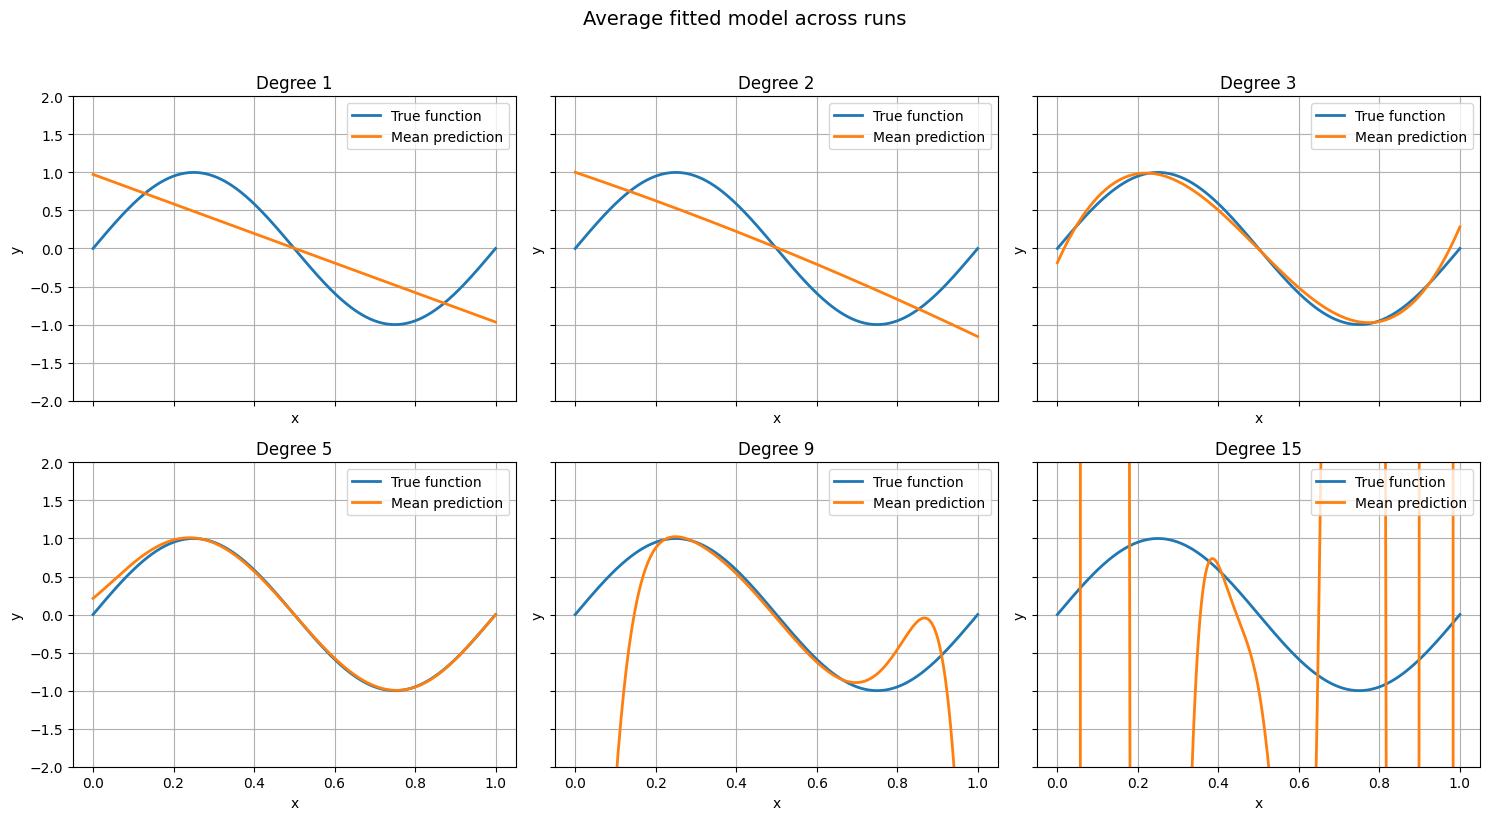

In [31]:

fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharex=True, sharey=True)
axes = axes.ravel()

for ax, degree in zip(axes, degrees):
    ax.plot(X_test, y_test_true, label="True function", linewidth=2)
    ax.plot(X_test, results[degree]["mean_prediction"], label="Mean prediction", linewidth=2)
    ax.set_title(f"Degree {degree}")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_ylim(-2, 2)
    ax.legend()

plt.suptitle("Average fitted model across runs", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

## 10. Training error and test error vs model complexity

This is the classic bias–variance picture.

Expected pattern:
- training error usually decreases as complexity increases
- test error often decreases first, then increases
- the minimum test error appears at an intermediate complexity

In [33]:

summary_rows = []
for degree in degrees:
    summary_rows.append({
        "degree": degree,
        "avg_train_mse": results[degree]["avg_train_mse"],
        "avg_test_mse": results[degree]["avg_test_mse"],
        "avg_bias2": results[degree]["avg_bias2"],
        "avg_variance": results[degree]["avg_variance"],
    })

summary_df = pd.DataFrame(summary_rows)
summary_df

,degree,avg_train_mse,avg_test_mse,avg_bias2,avg_variance
0,1,0.233632,2.302455e-01,1.986427e-01,3.160285e-02
1,2,0.202678,3.024937e-01,2.055122e-01,9.698144e-02
2,3,0.051615,2.443741e-02,5.268090e-03,1.916932e-02
3,5,0.041556,1.071884e-01,2.634392e-03,1.045540e-01
4,9,0.035359,1.071431e+03,1.551452e+01,1.055916e+03
5,15,0.011536,1.678479e+09,1.293082e+06,1.677186e+09


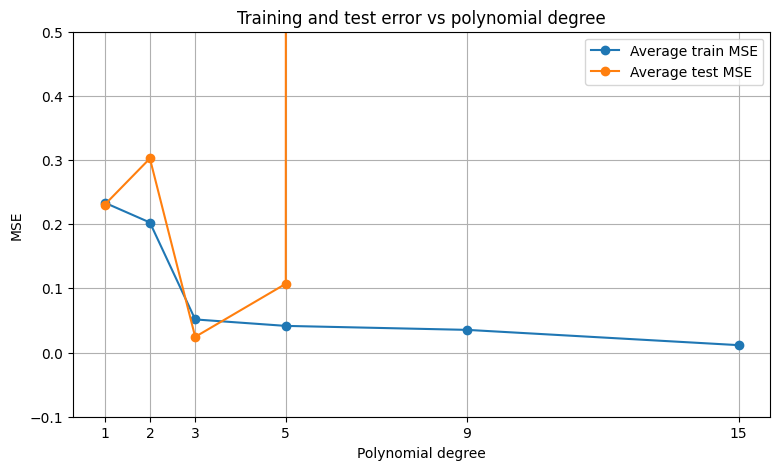

In [37]:

plt.plot(summary_df["degree"], summary_df["avg_train_mse"], marker="o", label="Average train MSE")
plt.plot(summary_df["degree"], summary_df["avg_test_mse"], marker="o", label="Average test MSE")
plt.title("Training and test error vs polynomial degree")
plt.xlabel("Polynomial degree")
plt.ylabel("MSE")
plt.xticks(summary_df["degree"])
plt.legend()
plt.ylim(-0.1, 0.5)

plt.show()

## 11. Bias squared and variance vs model complexity

Now we directly estimate the two components.

For each degree:
- **bias²** = average squared difference between mean prediction and true function
- **variance** = average variation of predictions across runs

Typical trend:
- low-degree models: high bias, low variance
- high-degree models: lower bias, higher variance

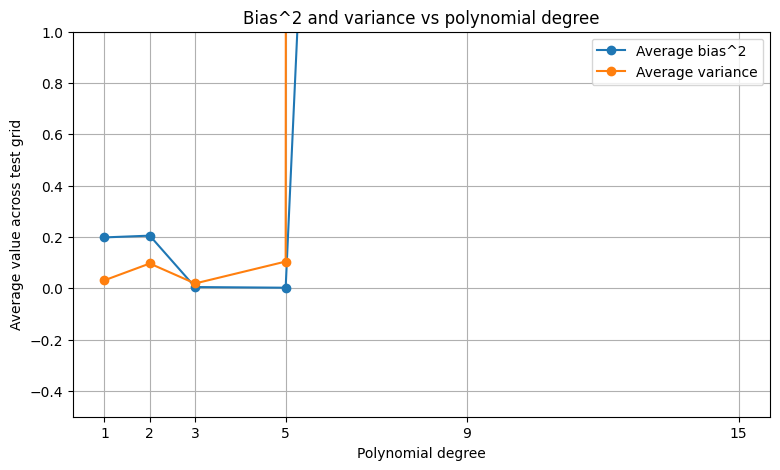

In [38]:

plt.plot(summary_df["degree"], summary_df["avg_bias2"], marker="o", label="Average bias^2")
plt.plot(summary_df["degree"], summary_df["avg_variance"], marker="o", label="Average variance")
plt.title("Bias^2 and variance vs polynomial degree")
plt.xlabel("Polynomial degree")
plt.ylabel("Average value across test grid")
plt.xticks(summary_df["degree"])
plt.legend()
plt.ylim(-0.5, 1)

plt.show()

## 12. Pointwise view for selected models

Sometimes it is helpful to show how bias² and variance change across the input domain.

Below we compare a simple model, a medium model, and a complex model.

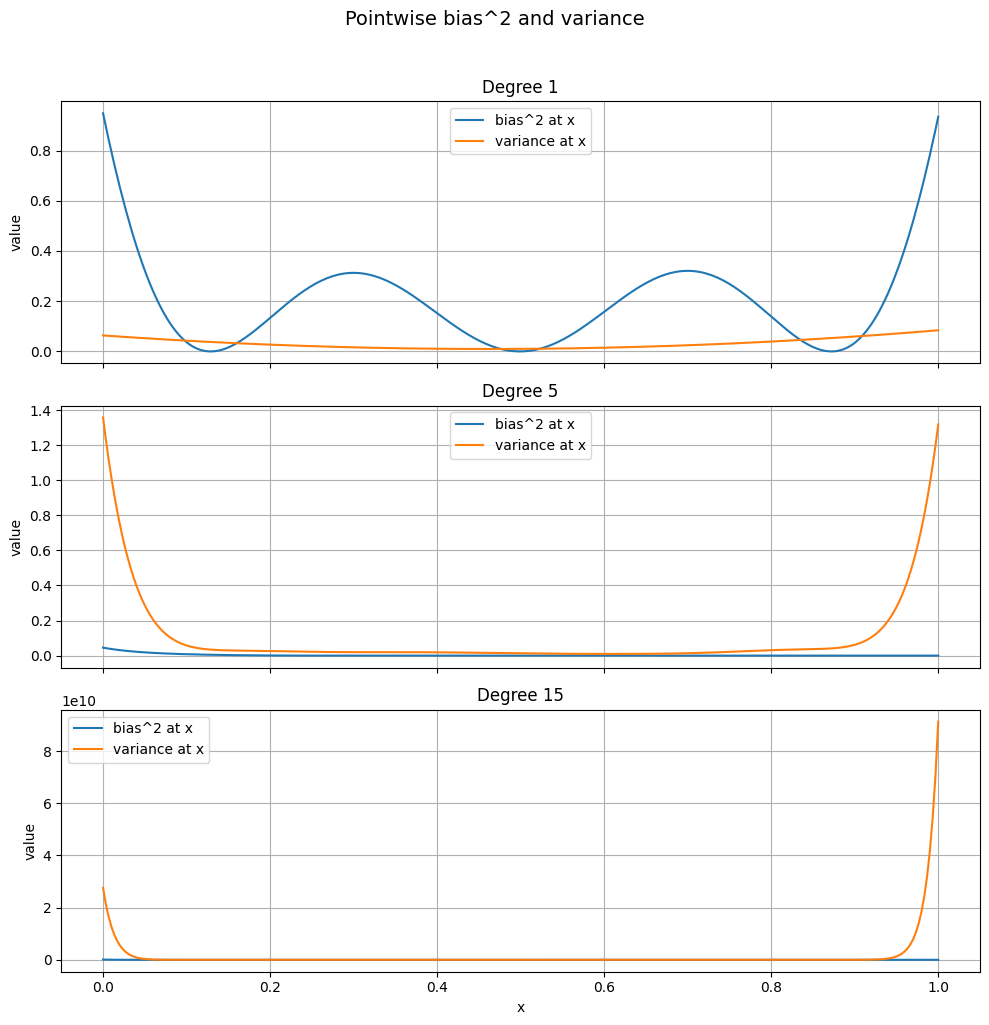

In [13]:

selected_degrees = [1, 5, 15]

fig, axes = plt.subplots(len(selected_degrees), 1, figsize=(10, 10), sharex=True)

for ax, degree in zip(axes, selected_degrees):
    ax.plot(X_test, results[degree]["bias2_per_x"], label="bias^2 at x")
    ax.plot(X_test, results[degree]["variance_per_x"], label="variance at x")
    ax.set_title(f"Degree {degree}")
    ax.set_ylabel("value")
    ax.legend()

axes[-1].set_xlabel("x")
plt.suptitle("Pointwise bias^2 and variance", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

## 13. Compact summary table

In [14]:

summary_df.round(4)

,degree,avg_train_mse,avg_test_mse,avg_bias2,avg_variance
0,1,0.2336,2.302000e-01,1.986000e-01,3.160000e-02
1,2,0.2027,3.025000e-01,2.055000e-01,9.700000e-02
2,3,0.0516,2.440000e-02,5.300000e-03,1.920000e-02
3,5,0.0416,1.072000e-01,2.600000e-03,1.046000e-01
4,9,0.0354,1.071431e+03,1.551450e+01,1.055916e+03
5,15,0.0115,1.678949e+09,1.289952e+06,1.677659e+09


## 14. Main conclusions

### What this notebook demonstrates
- A **simple model** cannot represent the target function well:
  - high bias
  - low variance

- A **very flexible model** can adapt strongly to each sampled training set:
  - lower bias
  - higher variance

- Best test performance often occurs at an **intermediate complexity**.

### Why this experiment is clean
- fixed test grid
- noiseless ground truth on the test grid
- fresh noisy training sample in each run

That is why the bias and variance estimates are easy to interpret.

## Possible extensions
- increase the training-set size and see variance decrease
- increase the noise level and see test error rise
- compare ordinary linear regression with Ridge regression